In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [2]:
df = pd.read_csv("../outputs/cleaned_inventory_data.csv")

In [3]:
engine = create_engine('sqlite:///../sql/inventory.db')

In [4]:
df.to_sql(
    name='inventory_sales',
    con=engine,
    if_exists='replace',
    index=False
)

1000

In [5]:
query = "SELECT * FROM inventory_sales LIMIT 5"

pd.read_sql(query, engine)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,MONTH,YEAR
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2,2023
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,4,2023
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,9,2023
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,8,2023
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,3,2023


In [6]:
query = """
SELECT SUM(Sales_Amount) AS total_sales
FROM inventory_sales
"""

pd.read_sql(query, engine)

,total_sales
0,5019265.23


In [7]:
query = """
SELECT Product_Category,
SUM(Sales_Amount) AS total_sales
FROM inventory_sales
GROUP BY Product_Category
ORDER BY total_sales DESC
"""

pd.read_sql(query, engine)

,Product_Category,total_sales
0,Clothing,1313474.36
1,Furniture,1260517.69
2,Electronics,1243499.64
3,Food,1201773.54


In [8]:
query = """
SELECT MONTH,
SUM(Sales_Amount) AS monthly_sales
FROM inventory_sales
GROUP BY MONTH
ORDER BY MONTH
"""

monthly_sales_sql = pd.read_sql(query, engine)

monthly_sales_sql

,MONTH,monthly_sales
0,1,495420.37
1,2,368919.36
2,3,402638.77
3,4,438992.61
4,5,389078.76
5,6,418458.34
6,7,374242.88
7,8,443171.28
8,9,367837.60
9,10,460378.78


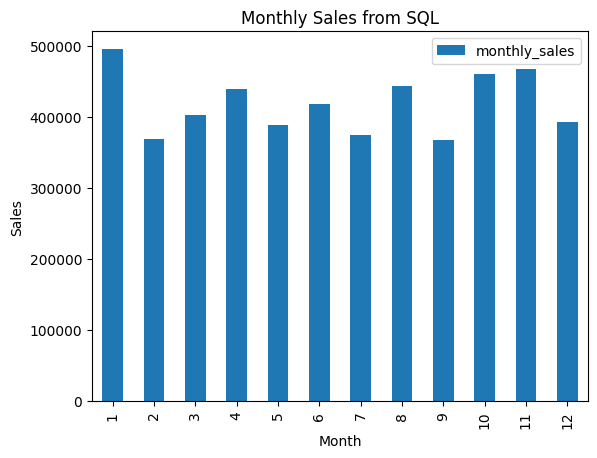

In [9]:
import matplotlib.pyplot as plt

monthly_sales_sql.plot(
    x='MONTH',
    y='monthly_sales',
    kind='bar'
)

plt.title("Monthly Sales from SQL")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [10]:
query = """
SELECT Product_Category,
SUM(Sales_Amount) AS total_sales
FROM inventory_sales
GROUP BY Product_Category
ORDER BY total_sales ASC
LIMIT 5
"""

pd.read_sql(query, engine)

,Product_Category,total_sales
0,Food,1201773.54
1,Electronics,1243499.64
2,Furniture,1260517.69
3,Clothing,1313474.36


In [11]:
monthly_sales_sql.to_csv(
    "../dashboard/monthly_sales_sql.csv",
    index=False
)